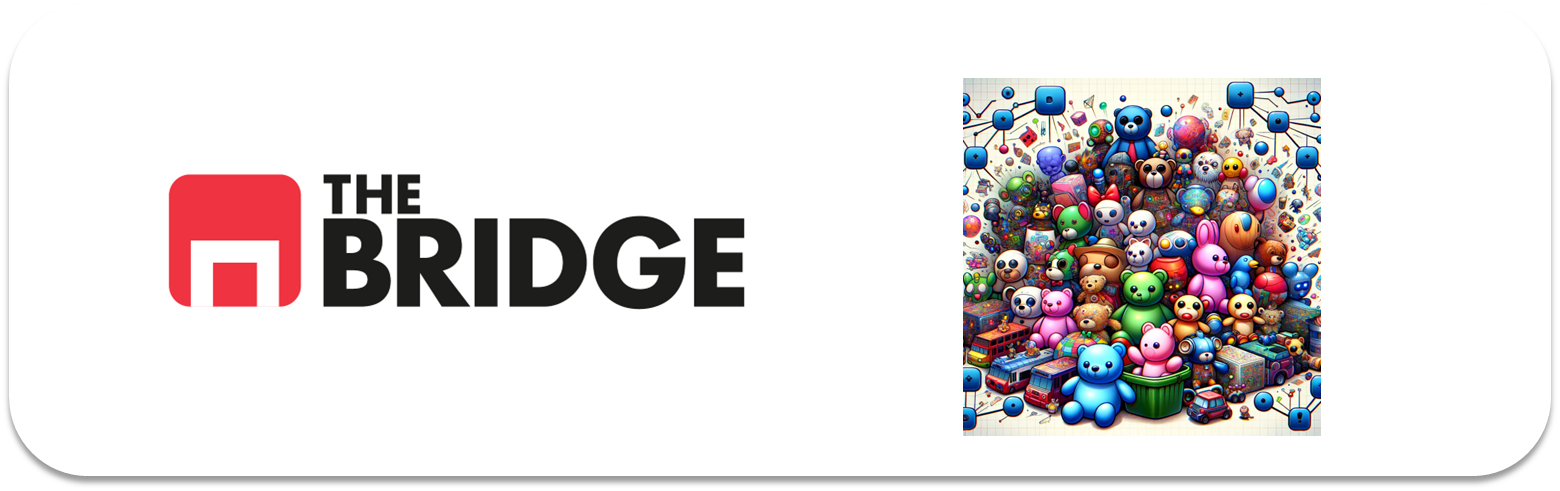

## PRACTICA OBLIGATORIA: **K-Means Clustering**

* La práctica obligatoria de esta unidad consiste en un ejercicio de modelado no supervisado sobre imágenes para practicar con el algoritmo k-means. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import numpy as np
import os
import pandas as pd

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt

import sklearn as sklearn
from sklearn.model_selection import train_test_split


import warnings
warnings.filterwarnings(action="ignore", message="^internal gelsd")
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score

## **#1**

Vamos a trabajar con un dataset también entre los "clásicos" (aunque a veces menos conocido) que es el de rostros Olivetti. Este dataset contiene 400 imágenes en escala de grises de 64 × 64 píxeles de rostros.   


Como en otros datasets de imágenes, estás están "aplanadas" de forma que cada pixel es una feature y por cada imagen hay $64\times 64 = 4096$ features.  

Se fotografiaron 40 personas diferentes (10 veces cada una) y esas fotografías se recogen en el dataset.  

La tarea habitual es entrenar un modelo que pueda predecir qué persona está representada en cada imagen, pero nosotros lo vamos a hacer de forma no supervisada. 



### #1.1


Carga el conjunto de datos usando la función `sklearn.datasets.fetch_olivetti_faces()`. Recuerda que se carga un "diccionario". Muestra su descripción acudiendo a la clave "DESCR".

In [2]:
df_olivetti = sklearn.datasets.fetch_olivetti_faces()

df_olivetti.DESCR


'.. _olivetti_faces_dataset:\n\nThe Olivetti faces dataset\n--------------------------\n\n`This dataset contains a set of face images`_ taken between April 1992 and\nApril 1994 at AT&T Laboratories Cambridge. The\n:func:`sklearn.datasets.fetch_olivetti_faces` function is the data\nfetching / caching function that downloads the data\narchive from AT&T.\n\n.. _This dataset contains a set of face images: https://cam-orl.co.uk/facedatabase.html\n\nAs described on the original website:\n\n    There are ten different images of each of 40 distinct subjects. For some\n    subjects, the images were taken at different times, varying the lighting,\n    facial expressions (open / closed eyes, smiling / not smiling) and facial\n    details (glasses / no glasses). All the images were taken against a dark\n    homogeneous background with the subjects in an upright, frontal position\n    (with tolerance for some side movement).\n\n**Data Set Characteristics:**\n\n=================   ==================

### #1.2 

Aunque no lo vas a usar hasta el final de la práctica, muestra el target. Luego cargalo todo en un mismo dataframe (tendrás que añadir el target) y obtén otro dataset con todas las imagenes reordenadas aleatoriamente (emplea por ejemplo el método `sample` del dataframe o el método que tú quieras)

In [3]:
df_olivetti.target

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  5,
        5,  5,  5,  5,  5,  5,  5,  5,  5,  6,  6,  6,  6,  6,  6,  6,  6,
        6,  6,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  8,  8,  8,  8,  8,
        8,  8,  8,  8,  8,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9, 10, 10,
       10, 10, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 13,
       13, 13, 13, 13, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 15, 15, 15,
       15, 15, 15, 15, 15, 15, 15, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 18, 18, 18, 18, 18, 18, 18,
       18, 18, 18, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 20, 20, 20, 20,
       20, 20, 20, 20, 20, 20, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 22,
       22, 22, 22, 22, 22

In [4]:
df = pd.DataFrame(df_olivetti.data)

In [5]:
df["target"] = df_olivetti.target

In [6]:
# df con imágenes reordenadas usando sample:

df_random = df.sample(frac=1, random_state=42)



### #1.3

Vamos a dividir en train y test, pero OJO RECUERDA QUE EN LOS PROBLEMAS NO SUPERVISADOS NO HAY SPLIT (porque no hay target), aquí lo hacemos para poder comparar posteriormente el clustering con la clasificación (ya que es uan práctica formativa).

Por tanto, divídelo en un conjunto de entrenamiento, un conjunto de validación y un conjunto de pruebas (80-10-10). Dado que el conjunto de datos es bastante pequeño, emplea un muestreo estratificado para asegurarse de que haya el mismo número de imágenes por persona en cada conjunto (estratificando por la columna que contenga el target)

NOTA: No hemos hecho hasta ahora la separación en tres sets, investiga por tu cuenta o bien haz primero un split 90-10 y luego otro split 89-11 sobre el de 80 (para que de los números aproximados), por ejemplo.

In [7]:
# haremos dos splits:
# uno con 90% train_val y 10% test:
train_val, test = train_test_split(df_random, test_size=0.1, random_state=42, stratify=df_random["target"])
# aqui nos quedamos con el 10% de test, y el 90% restante lo dividiremos en train y val.

# aqui usamos train_val para hacer el split de train y val.
# otro con: del 90% de train_val, sacamos 89% train y 11% val, daría ese 80/10 aprox:
train, val = train_test_split(train_val, test_size=0.111, random_state=42, stratify=train_val["target"])

### #1.4

Crea los pares X,y para train, validation y test.

In [8]:
# para X, y de train:
X_train = train.drop("target", axis=1)
y_train = train["target"]

# X,y de validación:
X_val = val.drop("target", axis=1)
y_val = val["target"]


# X, y de test:
X_test = test.drop("target", axis=1)
y_test = test["target"]

In [9]:
# confirmamos que estén correctos los splits:
print(X_train.shape, y_train.shape)  
print(X_val.shape, y_val.shape)  
print(X_test.shape, y_test.shape)

(320, 4096) (320,)
(40, 4096) (40,)
(40, 4096) (40,)


Utiliza la siguiente función para visualizar alguna de las caras (observa que tienes que dar la X y la y, usa iloc en ambos datasets)

In [10]:
# con iloc seleccionaremos un rango de filas.

def plot_faces(faces, labels, n_cols=5):
    faces = faces.reshape(-1, 64, 64)
    n_rows = (len(faces) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols, n_rows * 1.1))
    for index, (face, label) in enumerate(zip(faces, labels)):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(face, cmap="gray")
        plt.axis("off")
        plt.title(label)
    plt.show()

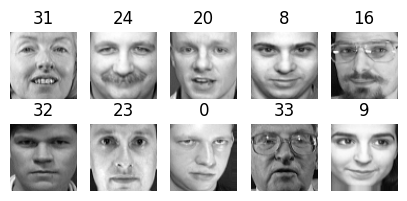

In [11]:
plot_faces(X_train.iloc[:10].values, y_train.iloc[:10].values)


### #1.5

Para acelerar las cosas, reduciremos la dimensionalidad de los datos utilizando PCA (técnica que veremos en el siguiente sprint). Modifica la siguiente celda de forma que las X se correspondan con las que has utilizado en el ejercicio anterior.

In [12]:
from sklearn.decomposition import PCA

pca = PCA(0.99)
X_train_pca = pca.fit_transform(X_train)
X_valid_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

pca.n_components_

np.int64(221)

### 1.6

Aquí viene la parte del león. A continuación, agrupa las imágenes utilizando K-Means sobre el dataset de train reducido en el ejercicio anterior. Emplea el método del máximo de score de silueta para obtener el mejor k, probando con K de 5 en 5 hasta 150. ¿Cuál es el k que proporciona el mejor score de silueta? NOTA: Emplea todas las features (no hace falta seleccionar, y ya están escaladas entre 0 y 1)

In [13]:
# agrupo usando k-means sobre X_train_pca:

kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
kmeans.fit(X_train_pca)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",10
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [14]:
# método max score de silueta para obtener el mejor k:

k_values = range(5, 151, 5) # (inicio, fin, paso) -> empieza en 5 hasta 151 de 5 en 5
silhouette_scores = [] # guarda el silhouette score de cada k

for k in k_values:
    
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # para cada valor de k entrenará un modelo k-means
    labels = kmeans.fit_predict(X_train_pca) # crea un array con el cluster asignado a cada muestra, donde se entrena y asigna cada punto a un cluster
    score = silhouette_score(X_train_pca, labels) # calcula el score de las siluetas para ver qué tan bien separados estan los clusters
    silhouette_scores.append(score) 
    print(f"k={k}, silhouette_score={score}") 


k=5, silhouette_score=0.10875304043292999
k=10, silhouette_score=0.10400134325027466
k=15, silhouette_score=0.10202882438898087
k=20, silhouette_score=0.10815119743347168
k=25, silhouette_score=0.1183207780122757
k=30, silhouette_score=0.1242789775133133
k=35, silhouette_score=0.15343543887138367
k=40, silhouette_score=0.14972467720508575
k=45, silhouette_score=0.1570156365633011
k=50, silhouette_score=0.17136496305465698
k=55, silhouette_score=0.17700645327568054
k=60, silhouette_score=0.17832671105861664
k=65, silhouette_score=0.1888718605041504
k=70, silhouette_score=0.18823663890361786
k=75, silhouette_score=0.1935921460390091
k=80, silhouette_score=0.19553512334823608
k=85, silhouette_score=0.19892582297325134
k=90, silhouette_score=0.19755558669567108
k=95, silhouette_score=0.19850018620491028
k=100, silhouette_score=0.19572782516479492
k=105, silhouette_score=0.2006794959306717
k=110, silhouette_score=0.19888713955879211
k=115, silhouette_score=0.18933424353599548
k=120, silhoue

In [15]:
# el k que proporciona mejor score de silueta:

best_k = list(k_values)[np.argmax(silhouette_scores)] # me da el valor de k que corresponde con el mayor silhouette score
best_score = max(silhouette_scores) # la silhouette mayor

print(f"\nMejor k: {best_k} con silhouette score: {best_score:.4f}")


Mejor k: 130 con silhouette score: 0.2020


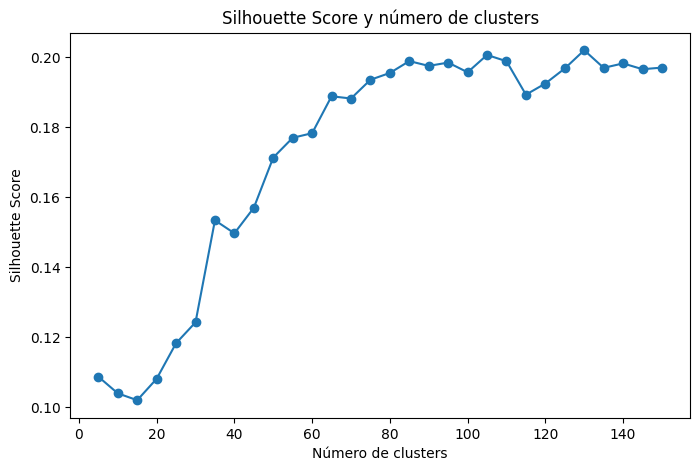

In [16]:
# vemos los clusters con siluetas:
plt.figure(figsize=(8,5))
plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel("Número de clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score y número de clusters")

plt.show();

### #1.7

Repite el ejercio anterior empleando ahora el método del codo de Inercia. ¿Sale algo más concluyente o que refuerce el anterior resultado?

In [17]:
# método de inercia:

k_values = range(5, 151, 5)
inertias = []

for k in k_values:
    
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train_pca)
    inertia = kmeans.inertia_
    inertias.append(inertia)
    print(f"k={k}, inertia={inertia}")


k=5, inertia=17074.90625
k=10, inertia=14760.6689453125
k=15, inertia=13501.85546875
k=20, inertia=12438.455078125
k=25, inertia=11331.7333984375
k=30, inertia=10486.666015625
k=35, inertia=9716.958984375
k=40, inertia=9142.744140625
k=45, inertia=8589.3203125
k=50, inertia=8013.9091796875
k=55, inertia=7575.404296875
k=60, inertia=7113.3623046875
k=65, inertia=6737.888671875
k=70, inertia=6412.4814453125
k=75, inertia=6052.830078125
k=80, inertia=5784.677734375
k=85, inertia=5451.2119140625
k=90, inertia=5212.1171875
k=95, inertia=4988.5712890625
k=100, inertia=4738.5439453125
k=105, inertia=4512.064453125
k=110, inertia=4260.25634765625
k=115, inertia=4073.1220703125
k=120, inertia=3869.54638671875
k=125, inertia=3668.685546875
k=130, inertia=3431.15771484375
k=135, inertia=3295.2841796875
k=140, inertia=3095.31640625
k=145, inertia=2931.04638671875
k=150, inertia=2769.722900390625


In [18]:
# el k que proporciona mejor inercia:

best_k_codo = list(k_values)[np.argmax(inertias)] # me da el valor de k que corresponde con la mayor inercia
best_score_codo = max(inertias) # la mayor inercia

print(f"\nMejor k: {best_k_codo} con inercia: {best_score_codo:.4f}")


Mejor k: 5 con inercia: 17074.9062


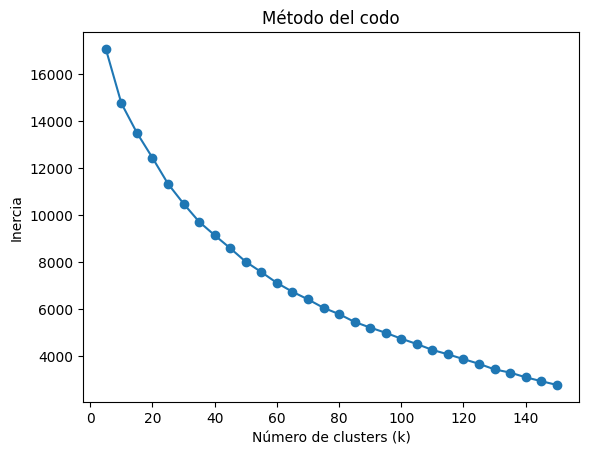

In [19]:
# visualizamos el codo:
import matplotlib.pyplot as plt

plt.plot(k_values, inertias, marker='o')
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.show();

El método de siluetas indica que el valor óptimo de k es aprox. 130, lo cual sugiere que el dataset tiene muchos patrones internos (grupos de observaciones con características similares separados en clusters mas específicos). Sin embargo, el método del codo no muestra un punto claro de inflexión, ya que la inercia se reduce progresivamente a medida que aumentan los clusters. Esta diferencia entre ambos métodos es habitual en datasets de alta dimensionalidad, como imágenes, en este caso. 

### #1.8

Quédate con el k obtenido con el método del score de silueta y asigna el modelo con ese k a una variable `best_model`

In [22]:
best_model = KMeans(n_clusters=best_k, random_state=42, n_init=10) # creamos el modelo
best_model.fit(X_train_pca) # lo entrenamos

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",130
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


### #1.9

Haz una valoración del método de clustering para el K elegido. Para ello crea un programa que recorra la lista de etiquetas dadas por "best_model" y que, haciendo uso de la función que ya te hemos proporcionado, pinte las caras asignadas a los 10 primeros clústeres. Ojo tendrás que hacer una pequeña adaptación porque las features de entrenamiento no son las features reales (son una "transformación" de estas) y si pasas el X de entrenamiento no verás nada. ¿Ves caras similares?

Cluster 0 (2 imágenes)


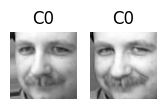

Cluster 1 (4 imágenes)


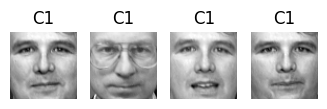

Cluster 2 (3 imágenes)


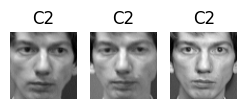

Cluster 3 (3 imágenes)


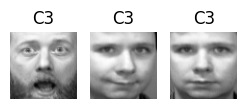

Cluster 4 (7 imágenes)


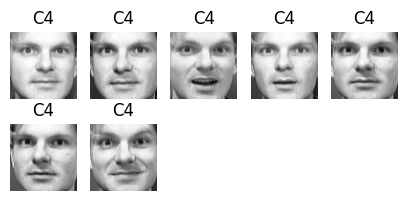

Cluster 5 (3 imágenes)


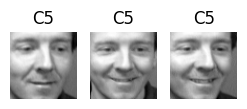

Cluster 6 (3 imágenes)


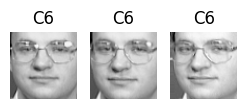

Cluster 7 (2 imágenes)


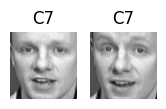

Cluster 8 (3 imágenes)


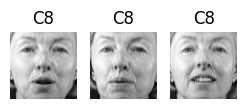

Cluster 9 (4 imágenes)


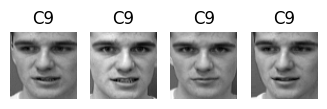

In [23]:
train_labels = best_model.labels_  # etiquetas asignadas por el modelo a cada muestra

for cluster_id in range(10): # recorremos los 10 primeros clusters
    indices = np.where(train_labels == cluster_id)[0] # índices de las muestras que pertenecen a este cluster
    faces = X_train.values[indices[:10]]    # cogemos las primeras 10 caras del cluster (en X_train original)
    labels = [f"C{cluster_id}"] * len(faces)
    
    print(f"Cluster {cluster_id} ({len(indices)} imágenes)")
    plot_faces(faces, labels)

Si, los clusters son bastante precisos. De estos 10, solamente en el 1 y 3 hay imágenes de distintas personas. Los demás, son de cada persona. 

## **#2**


### #2.1


Continuando con el conjunto de datos de caras Olivetti, entrena un clasificador para predecir qué persona está representada en cada imagen, y evalúalo en el conjunto de validación. Utiliza un RandomForest con 150 submodelos o estimadores (y el resto de hiperparámetros déjalos a su valor por defecto)

### #2.2

Utiliza K-Means como una herramienta de reducción de dimensionalidad y entrena un clasificador en el conjunto reducido. Para ello emplea el método transform de manera que ahora las features de entrada sean las distancias de cada punto a los centroides del modelo "best_model" de la parte anterior. Por ejemplo:
```python
X_train_reduced = best_model.transform(X_train_pca) 
```


Ojo lo tienes que aplicar a todos los datasets. Luego vuelve a entrenar un RandomForest sobre este dataset y evalualo contra el dataset de validacion.

### #2.3 EXTRA VOLUNTARIO

Busca el número de clusters k que generen un algoritmo kmeans que a su vez sus distancias a los centroides sean las features de un clasificador RandomForest y que permita al clasificador obtener el mejor rendimiento: ¿Qué rendimiento puedes alcanzar? (en terminos de Accuracy)